In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

sns.set_theme(style='whitegrid')

In [3]:
df = pd.read_csv(r'C:\Users\admin\Desktop\Tarek-Python\next exam\Processed.csv')

In [4]:
df.head()

,date,Year,Month,DOY,T2M,RH2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_SW_DWN,T2MDEW,Station,BMD_Rainfall,Rain_lag1,Rain_lag2,Rain_7day_avg,Temp_lag1,Humidity_lag1,Pressure_lag1,Station_Mean_Rainfall
0,1984-01-08,1984,1,8,18.75,49.81,101.65,2.74,37.1,15.84,7.49,Barisal,0.0,0.0,0.0,0.0,19.11,51.81,101.56,5.86003
1,1984-01-09,1984,1,9,19.03,50.34,101.49,2.36,59.5,14.54,7.82,Barisal,0.0,0.0,0.0,0.0,18.75,49.81,101.65,5.86003
2,1984-01-10,1984,1,10,19.26,45.34,101.42,2.20,78.8,8.07,6.57,Barisal,0.0,0.0,0.0,0.0,19.03,50.34,101.49,5.86003
3,1984-01-11,1984,1,11,19.12,46.39,101.48,2.34,0.0,15.46,6.51,Barisal,0.0,0.0,0.0,0.0,19.26,45.34,101.42,5.86003
4,1984-01-12,1984,1,12,19.32,48.82,101.45,2.72,0.0,15.59,7.67,Barisal,0.0,0.0,0.0,0.0,19.12,46.39,101.48,5.86003


In [5]:
df.shape

(397902, 20)

In [6]:
df.columns

Index(['date', 'Year', 'Month', 'DOY', 'T2M', 'RH2M', 'PS', 'WS2M',
       'CLOUD_AMT', 'ALLSKY_SFC_SW_DWN', 'T2MDEW', 'Station', 'BMD_Rainfall',
       'Rain_lag1', 'Rain_lag2', 'Rain_7day_avg', 'Temp_lag1', 'Humidity_lag1',
       'Pressure_lag1', 'Station_Mean_Rainfall'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397902 entries, 0 to 397901
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   date                   397902 non-null  object 
 1   Year                   397902 non-null  int64  
 2   Month                  397902 non-null  int64  
 3   DOY                    397902 non-null  int64  
 4   T2M                    397902 non-null  float64
 5   RH2M                   397902 non-null  float64
 6   PS                     397902 non-null  float64
 7   WS2M                   397902 non-null  float64
 8   CLOUD_AMT              397902 non-null  float64
 9   ALLSKY_SFC_SW_DWN      397902 non-null  float64
 10  T2MDEW                 397902 non-null  float64
 11  Station                397902 non-null  object 
 12  BMD_Rainfall           397902 non-null  float64
 13  Rain_lag1              397902 non-null  float64
 14  Rain_lag2              397902 non-nu

In [8]:
df.isnull().sum()

date                     0
Year                     0
Month                    0
DOY                      0
T2M                      0
RH2M                     0
PS                       0
WS2M                     0
CLOUD_AMT                0
ALLSKY_SFC_SW_DWN        0
T2MDEW                   0
Station                  0
BMD_Rainfall             0
Rain_lag1                0
Rain_lag2                0
Rain_7day_avg            0
Temp_lag1                0
Humidity_lag1            0
Pressure_lag1            0
Station_Mean_Rainfall    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df['date'].dtype

dtype('<M8[ns]')

In [12]:
df['Rain_Today'] = (df['BMD_Rainfall'] > 0).astype(int)

In [13]:
df['Rain_Today'].value_counts()

Rain_Today
0    269930
1    127972
Name: count, dtype: int64

In [14]:
df['Rain_Today'].value_counts(normalize=True) * 100

Rain_Today
0    67.838312
1    32.161688
Name: proportion, dtype: float64

In [15]:
df = df.sort_values(
    by=['Station','date']
).reset_index(drop=True)

In [16]:
df['Rain_lag1'] = (
    df.groupby('Station')['BMD_Rainfall']
      .shift(1)
)

In [17]:
df['Temp_lag1'] = (
    df.groupby('Station')['T2M']
      .shift(1)
)

In [18]:
df['Humidity_lag1'] = (
    df.groupby('Station')['RH2M']
      .shift(1)
)

In [19]:
df['Pressure_lag1'] = (
    df.groupby('Station')['PS']
      .shift(1)
)

In [20]:
df['Wind_lag1'] = (
    df.groupby('Station')['WS2M']
      .shift(1)
)

In [21]:
df['Cloud_lag1'] = (
    df.groupby('Station')['CLOUD_AMT']
      .shift(1)
)

In [22]:
df['Solar_lag1'] = (
    df.groupby('Station')['ALLSKY_SFC_SW_DWN']
      .shift(1)
)

In [23]:
df['DewPoint_lag1'] = (
    df.groupby('Station')['T2MDEW']
      .shift(1)
)

In [24]:
previous_day_features = [
    'Rain_lag1',
    'Temp_lag1',
    'Humidity_lag1',
    'Pressure_lag1',
    'Wind_lag1',
    'Cloud_lag1',
    'Solar_lag1',
    'DewPoint_lag1'
]

df[
    ['Station','date']
    + previous_day_features
    + ['Rain_Today']
].head(15)

,Station,date,Rain_lag1,Temp_lag1,Humidity_lag1,Pressure_lag1,Wind_lag1,Cloud_lag1,Solar_lag1,DewPoint_lag1,Rain_Today
0,Barisal,1984-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,Barisal,1984-01-09,0.0,18.75,49.81,101.65,2.74,37.1,15.84,7.49,0
2,Barisal,1984-01-10,0.0,19.03,50.34,101.49,2.36,59.5,14.54,7.82,0
3,Barisal,1984-01-11,0.0,19.26,45.34,101.42,2.20,78.8,8.07,6.57,0
4,Barisal,1984-01-12,0.0,19.12,46.39,101.48,2.34,0.0,15.46,6.51,0
5,Barisal,1984-01-13,0.0,19.32,48.82,101.45,2.72,0.0,15.59,7.67,0
6,Barisal,1984-01-14,0.0,19.80,45.39,101.19,1.87,0.0,15.77,6.79,0
7,Barisal,1984-01-15,0.0,21.58,42.78,101.01,0.98,84.9,14.51,7.63,0
8,Barisal,1984-01-16,0.0,21.16,52.02,101.19,2.03,1.0,15.75,10.54,0
9,Barisal,1984-01-17,0.0,22.06,55.89,101.06,1.79,34.7,14.49,12.13,0


In [25]:
df[previous_day_features].isnull().sum()

Rain_lag1        34
Temp_lag1        34
Humidity_lag1    34
Pressure_lag1    34
Wind_lag1        34
Cloud_lag1       34
Solar_lag1       34
DewPoint_lag1    34
dtype: int64

In [26]:
df = df.dropna(
    subset=previous_day_features
).reset_index(drop=True)

In [27]:
df[previous_day_features].isnull().sum()

Rain_lag1        0
Temp_lag1        0
Humidity_lag1    0
Pressure_lag1    0
Wind_lag1        0
Cloud_lag1       0
Solar_lag1       0
DewPoint_lag1    0
dtype: int64

In [28]:
df['Rain_Today'].value_counts()

Rain_Today
0    269896
1    127972
Name: count, dtype: int64

In [29]:
df.shape

(397868, 25)

In [30]:
columns_to_drop = [
    'Rain_lag2',
    'Rain_7day_avg',
    'Station_Mean_Rainfall'
]

df = df.drop(
    columns=columns_to_drop,
    errors='ignore'
)

In [31]:
df.columns

Index(['date', 'Year', 'Month', 'DOY', 'T2M', 'RH2M', 'PS', 'WS2M',
       'CLOUD_AMT', 'ALLSKY_SFC_SW_DWN', 'T2MDEW', 'Station', 'BMD_Rainfall',
       'Rain_lag1', 'Temp_lag1', 'Humidity_lag1', 'Pressure_lag1',
       'Rain_Today', 'Wind_lag1', 'Cloud_lag1', 'Solar_lag1', 'DewPoint_lag1'],
      dtype='object')

In [32]:
df_encoded = pd.get_dummies(
    df,
    columns=['Station'],
    drop_first=True
)

In [33]:
df_encoded.shape

(397868, 54)

In [34]:
df_encoded.head()

,date,Year,Month,DOY,T2M,RH2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_SW_DWN,...,Station_Rangpur,Station_Sandwip,Station_Satkhira,Station_Sitakunda,Station_Srimangal,Station_Sylhet,Station_Tangail,Station_Teknaf,Station_chuadanga,Station_sydpur
0,1984-01-09,1984,1,9,19.03,50.34,101.49,2.36,59.5,14.54,...,False,False,False,False,False,False,False,False,False,False
1,1984-01-10,1984,1,10,19.26,45.34,101.42,2.20,78.8,8.07,...,False,False,False,False,False,False,False,False,False,False
2,1984-01-11,1984,1,11,19.12,46.39,101.48,2.34,0.0,15.46,...,False,False,False,False,False,False,False,False,False,False
3,1984-01-12,1984,1,12,19.32,48.82,101.45,2.72,0.0,15.59,...,False,False,False,False,False,False,False,False,False,False
4,1984-01-13,1984,1,13,19.80,45.39,101.19,1.87,0.0,15.77,...,False,False,False,False,False,False,False,False,False,False


In [35]:
feature_cols = [
    'Year',
    'Month',
    'DOY',
    
    'Rain_lag1',
    
    'Temp_lag1',
    'Humidity_lag1',
    'Pressure_lag1',
    'Wind_lag1',
    'Cloud_lag1', 
    'Solar_lag1', 
    'DewPoint_lag1'
]    

In [36]:
X = df_encoded[feature_cols]

y = df_encoded['Rain_Today']

In [37]:
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (397868, 11)
y shape: (397868,)


In [38]:
X.dtypes

Year               int64
Month              int64
DOY                int64
Rain_lag1        float64
Temp_lag1        float64
Humidity_lag1    float64
Pressure_lag1    float64
Wind_lag1        float64
Cloud_lag1       float64
Solar_lag1       float64
DewPoint_lag1    float64
dtype: object

In [39]:
train_data = df_encoded[
    df_encoded['Year'] <= 2013
]

test_data = df_encoded[
    df_encoded['Year'] >= 2014
]

In [40]:
X_train = train_data[feature_cols]
y_train = train_data['Rain_Today']

X_test = test_data[feature_cols]
y_test = test_data['Rain_Today']

In [41]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (360604, 11)
X_test: (37264, 11)
y_train: (360604,)
y_test: (37264,)


In [42]:
scaler = StandardScaler()

X_train_scaled  = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [43]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

In [44]:
model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [45]:
y_pred = model.predict(
    X_test_scaled
)

In [46]:
y_probability = model.predict_proba(
    X_test_scaled
)

In [47]:
rain_probability = model.predict_proba(
    X_test_scaled
)[:, 1]

In [48]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print('Accuracy:', accuracy)
print('Accuracy:', accuracy * 100, '%')

Accuracy: 0.826320309145556
Accuracy: 82.6320309145556 %


In [49]:
precision = precision_score(
    y_test,
    y_pred
)

print('Precision:', precision)
print('Precision:', precision * 100, '%')

Precision: 0.6734624991561466
Precision: 67.34624991561466 %


In [50]:
recall = recall_score(
    y_test,
    y_pred
)

print('Recall:', recall)
print('Recall:', recall * 100, '%')

Recall: 0.8591852553612953
Recall: 85.91852553612954 %


In [51]:
f1 = f1_score(
    y_test,
    y_pred
)

print('F1 Score:', f1)
print('F1 Score:', f1 * 100, '%')

F1 Score: 0.7550711474417197
F1 Score: 75.50711474417197 %


In [52]:
print('===== Previous-Day Logistic Regression =====')

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))

===== Previous-Day Logistic Regression =====
Accuracy : 0.826320309145556
Precision: 0.6734624991561466
Recall   : 0.8591852553612953
F1 Score : 0.7550711474417197


In [53]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'No Rain',
            'Rain'
        ]
    )
)

              precision    recall  f1-score   support

     No Rain       0.93      0.81      0.87     25653
        Rain       0.67      0.86      0.76     11611

    accuracy                           0.83     37264
   macro avg       0.80      0.84      0.81     37264
weighted avg       0.85      0.83      0.83     37264



In [55]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[20816  4837]
 [ 1635  9976]]


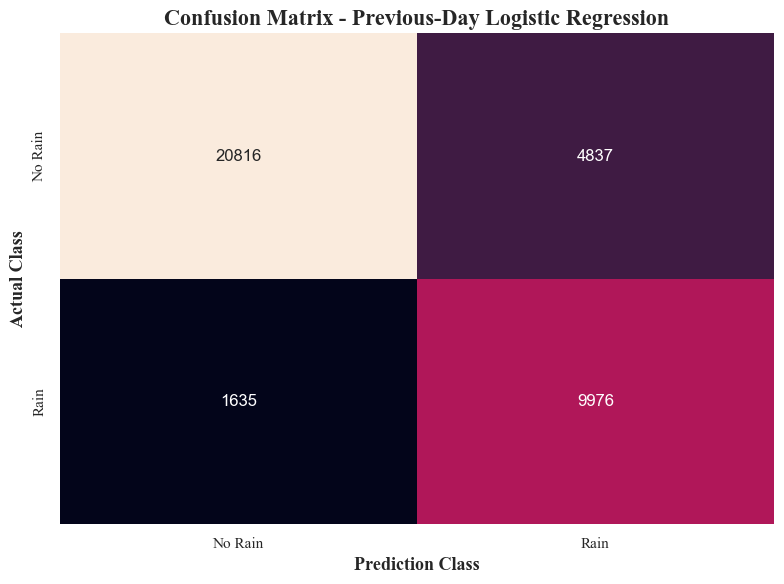

In [57]:
plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cbar=False
)

ax.set_xlabel(
    'Prediction Class',
    fontname='Times New Roman',
    fontweight='bold',
    fontsize=13
)

ax.set_ylabel(
    'Actual Class',
    fontname='Times New Roman',
    fontweight='bold',
    fontsize=13
)


ax.set_title(
    'Confusion Matrix - Previous-Day Logistic Regression',
    fontname='Times New Roman',
    fontweight='bold',
    fontsize=16
)


ax.set_xticklabels(
    ['No Rain', 'Rain'],
    fontname='Times New Roman'
)

ax.set_yticklabels(
    ['No Rain', 'Rain'],
    fontname='Times New Roman'
)

plt.tight_layout()

plt.savefig(
    'confusion_matrix_previous_day_600dpi.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [59]:
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0]
})

In [61]:
coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
5,Humidity_lag1,0.932212
8,Cloud_lag1,0.862030
4,Temp_lag1,0.852534
3,Rain_lag1,0.271269
7,Wind_lag1,0.039864
1,Month,-0.048804
10,DewPoint_lag1,-0.135985
0,Year,-0.136166
2,DOY,-0.359540
6,Pressure_lag1,-0.415466


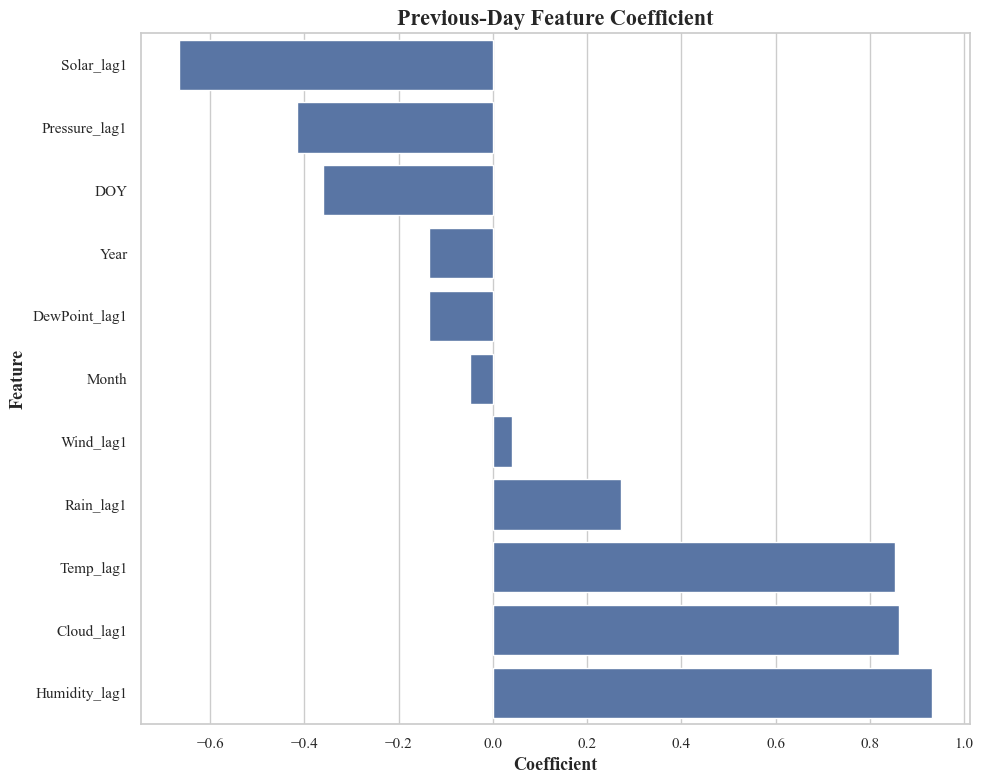

In [64]:
plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=coefficients.sort_values(
        by='Coefficient'
    ),
    x='Coefficient',
    y='Feature'
)

ax.set_xlabel(
    'Coefficient',
    fontname='Times New Roman',
    fontweight='bold',
    fontsize=13
)

ax.set_ylabel(
    'Feature',
    fontname='Times New Roman',
    fontweight='bold',
    fontsize=13
)

ax.set_title(
    'Previous-Day Feature Coefficient',
    fontname='Times New Roman',
    fontweight='bold',
    fontsize=16
)

plt.xticks(
    fontname='Times New Roman'
)

plt.yticks(
    fontname='Times New Roman'
)

plt.tight_layout()

plt.savefig(
    'previous_day_coefficient_600dpi.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()



In [65]:
results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score':[
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

results

,Metric,Score
0,Accuracy,0.826320
1,Precision,0.673462
2,Recall,0.859185
3,F1 Score,0.755071


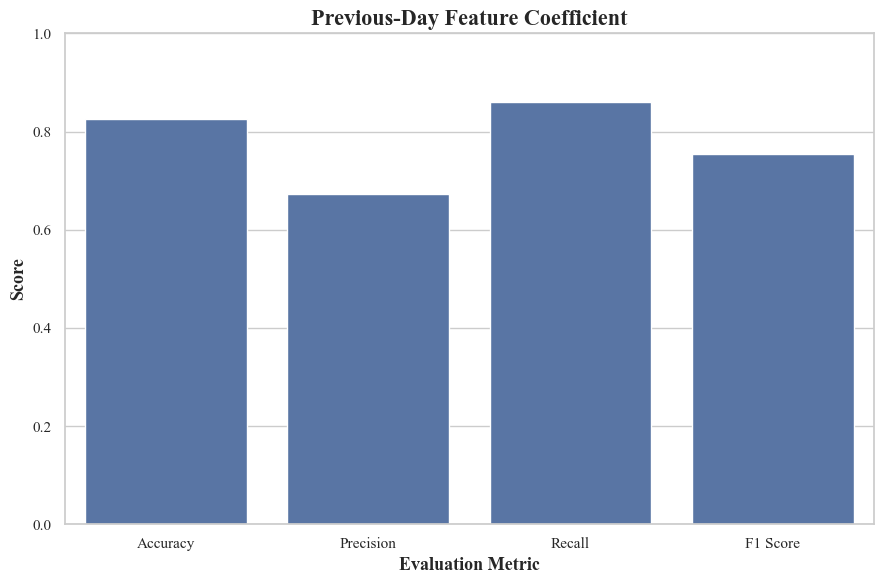

In [67]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=results,
    x ='Metric',
    y='Score'
)

ax.set_xlabel(
    'Evaluation Metric',
    fontname='Times New Roman',
    fontweight='bold',
    fontsize=13
)

ax.set_ylabel(
    'Score',
    fontname='Times New Roman',
    fontweight='bold',
    fontsize=13
)

ax.set_title(
    'Previous-Day Feature Coefficient',
    fontname='Times New Roman',
    fontweight='bold',
    fontsize=16
)

plt.xticks(
    fontname='Times New Roman'
)

plt.yticks(
    fontname='Times New Roman'
)

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    'previous_day_coefficient_600dpi.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [68]:
def predict_current_day_rain(
    previous_rain,
    previous_temperature,
    previous_humidity,
    previous_pressure,
    previous_wind,
    previous_cloud,
    previous_solar,
    previous_dewpoint,
    year,
    month,
    doy
):
    
    input_data = pd.DataFrame({
        'Year': [year],
        'Month': [month],
        'DOY': [doy],
        'Rain_lag1': [previous_rain],
        'Temp_lag1': [previous_temperature],
        'Humidity_lag1': [previous_humidity],
        'Pressure_lag1': [previous_pressure],
        'Wind_lag1': [previous_wind],
        'Cloud_lag1': [previous_cloud],
        'Solar_lag1': [previous_solar],
        'DewPoint_lag1': [previous_dewpoint]
    })
    
    input_scaled = scaler.transform(
        input_data
    )
    
    prediction = model.predict(
        input_scaled
    )[0]
    
    probability = model.predict_proba(
        input_scaled
    )[0, 1]
    
    if prediction == 1:
        result = "Rain"
    else:
        result = "No Rain"
    
    print("Prediction:", result)
    print(
        "Rain Probability:",
        round(probability * 100, 2),
        "%"
    )
    
    return prediction, probability

In [69]:
test_data[
    [
        'Year',
        'Month',
        'DOY',
        'Rain_lag1',
        'Temp_lag1',
        'Humidity_lag1',
        'Pressure_lag1',
        'Wind_lag1',
        'Cloud_lag1',
        'Solar_lag1',
        'DewPoint_lag1'
    ]
].head(1)

,Year,Month,DOY,Rain_lag1,Temp_lag1,Humidity_lag1,Pressure_lag1,Wind_lag1,Cloud_lag1,Solar_lag1,DewPoint_lag1
10950,2014,1,1,0.0,16.71,80.86,101.68,2.51,3.71,14.24,13.26


In [70]:
sample = X_test.iloc[[0]]

sample_scaled = scaler.transform(
    sample
)

prediction = model.predict(
    sample_scaled
)[0]

probability = model.predict_proba(
    sample_scaled
)[0, 1]

print("Prediction:", prediction)

if prediction == 1:
    print("Classification: Rain")
else:
    print("Classification: No Rain")

print(
    "Rain Probability:",
    round(probability * 100, 2),
    "%"
)

Prediction: 0
Classification: No Rain
Rain Probability: 3.81 %


In [71]:
final_results = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
}

final_results

{'Accuracy': 0.826320309145556,
 'Precision': 0.6734624991561466,
 'Recall': 0.8591852553612953,
 'F1 Score': 0.7550711474417197}

In [72]:
results.to_csv(
    'previous_day_logistic_regression_results.csv',
    index=False
)

In [74]:
print("===== FINAL MODEL CHECK =====")

print("Features used:", len(feature_cols))
print("Features:", feature_cols)

print("\nModel Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

===== FINAL MODEL CHECK =====
Features used: 11
Features: ['Year', 'Month', 'DOY', 'Rain_lag1', 'Temp_lag1', 'Humidity_lag1', 'Pressure_lag1', 'Wind_lag1', 'Cloud_lag1', 'Solar_lag1', 'DewPoint_lag1']

Model Performance:
Accuracy : 0.826320309145556
Precision: 0.6734624991561466
Recall   : 0.8591852553612953
F1 Score : 0.7550711474417197
